Лабораторна робота №3

1. Імпортуємо необхідні бібліотеки.

In [1]:
!pip uninstall -y torch torchvision torchaudio sentence-transformers transformers
!pip cache purge

!pip install torch==2.8.0 torchvision==0.23.0 torchaudio==2.8.0 \
    sentence-transformers==3.3.1 transformers==4.46.3
import os
import numpy as np
import pandas as pd
from tqdm import tqdm

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import precision_recall_fscore_support

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

import matplotlib.pyplot as plt
import seaborn as sns

from sentence_transformers import SentenceTransformer

import joblib

Found existing installation: torch 2.8.0
Uninstalling torch-2.8.0:
  Successfully uninstalled torch-2.8.0
Found existing installation: torchvision 0.23.0
Uninstalling torchvision-0.23.0:
  Successfully uninstalled torchvision-0.23.0
Found existing installation: torchaudio 2.8.0
Uninstalling torchaudio-2.8.0:
  Successfully uninstalled torchaudio-2.8.0
Found existing installation: sentence-transformers 3.3.1
Uninstalling sentence-transformers-3.3.1:
  Successfully uninstalled sentence-transformers-3.3.1
Found existing installation: transformers 4.46.3
Uninstalling transformers-4.46.3:
  Successfully uninstalled transformers-4.46.3
Files removed: 30 (256.2 MB)
   ---------------------------------------- 0.0/241.3 MB ? eta -:--:--
   ---------------------------------------- 2.9/241.3 MB 16.8 MB/s eta 0:00:15
   - -------------------------------------- 7.1/241.3 MB 18.9 MB/s eta 0:00:13
   -- ------------------------------------- 12.3/241.3 MB 21.4 MB/s eta 0:00:11
   --- -----------------


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


2.	Зчитуємо датасет, виводимо його та існуючі сентименти і кількість записів на кожен.

In [2]:
df = pd.read_csv("Corona_NLP_train_small.csv", encoding="ISO-8859-1")
display(df.head())
print(df.columns)
print(df['Sentiment'].value_counts())

,UserName,ScreenName,Location,TweetAt,OriginalTweet,Sentiment
0,34888,79840,Lagos,06-04-2020,Without the there would not be any problem wh...,Neutral
1,39363,84315,NaN,09-04-2020,Rice &amp; wheat prices surge amid fears Covid...,Extremely Negative
2,3943,48895,NaN,16-03-2020,When the government says to start social dista...,Positive
3,12001,56953,irlande du nord,19-03-2020,What the shops are doing is obeying the law of...,Positive
4,35519,80471,"Zaria, Nigeria",07-04-2020,Kaduna State Task Force on Covid 19 led by the...,Negative


Index(['UserName', 'ScreenName', 'Location', 'TweetAt', 'OriginalTweet',
       'Sentiment'],
      dtype='object')
Sentiment
Positive              1140
Negative               987
Neutral                783
Extremely Positive     671
Extremely Negative     535
Name: count, dtype: int64


3.	Проведемо попередню обробку. Підготуємо текст: lowercase, видалення URL, @username, непотрібних символів; збережемо колонку text_clean.

In [3]:
import re

def clean_text(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', ' ', text)   # url
    text = re.sub(r'@\w+', ' ', text)               # mentions
    text = re.sub(r'[^a-z0-9\s#]', ' ', text)       # лишні символи (англ)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

tqdm.pandas()
df['text_clean'] = df['OriginalTweet'].progress_map(clean_text)
display(df[['OriginalTweet','text_clean']].head())


100%|██████████| 4116/4116 [00:00<00:00, 80707.20it/s]


,OriginalTweet,text_clean
0,Without the there would not be any problem wh...,without the there would not be any problem wha...
1,Rice &amp; wheat prices surge amid fears Covid...,rice amp wheat prices surge amid fears covid 1...
2,When the government says to start social dista...,when the government says to start social dista...
3,What the shops are doing is obeying the law of...,what the shops are doing is obeying the law of...
4,Kaduna State Task Force on Covid 19 led by the...,kaduna state task force on covid 19 led by the...


4.	Створюємо ембеддинги (вектори розміру ~384 (для all-MiniLM-L6-v2))(sentence-transformers).

In [4]:
model = SentenceTransformer('all-MiniLM-L6-v2')

texts = df['text_clean'].tolist()
embeddings = model.encode(texts, show_progress_bar=True, batch_size=64)
embeddings = np.array(embeddings)
print("Embeddings shape:", embeddings.shape)

# додаємо в DataFrame, опціонально зберігаємо на диск
df_emb = pd.DataFrame(embeddings)
df_emb['sentiment'] = df['Sentiment'].values

Batches:   0%|          | 0/65 [00:00<?, ?it/s]

Embeddings shape: (4116, 384)


5.	Розділяємо датасет на тренувальні та тестові дані.

In [5]:
X = embeddings
y = df['Sentiment'].values
le = LabelEncoder()
y_enc = le.fit_transform(y)  # зберігаємо le для декодування

X_train, X_test, y_train, y_test = train_test_split(X, y_enc, test_size=0.2, random_state=42, stratify=y_enc)
print(X_train.shape, X_test.shape)

(3292, 384) (824, 384)


6.	Описуємо функцію для тренування і оцінки моделей.

In [6]:
def evaluate_model(clf, X_tr, X_te, y_tr, y_te, class_names):
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_te)
    acc = accuracy_score(y_te, y_pred)
    report = classification_report(y_te, y_pred, target_names=class_names, output_dict=True)
    cm = confusion_matrix(y_te, y_pred)
    return acc, report, cm, y_pred

7.	Навчаємо моделі без PCA.

In [7]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000),
    "SVM": SVC(kernel='linear', probability=True),
    "RandomForest": RandomForestClassifier(n_estimators=200),
    "NaiveBayes": GaussianNB()
}

results_no_pca = {}
class_names = le.classes_.tolist()

for name, model in models.items():
    print("Training:", name)
    acc, report, cm, y_pred = evaluate_model(model, X_train, X_test, y_train, y_test, class_names)
    results_no_pca[name] = {"accuracy": acc, "report": report, "confusion_matrix": cm}
    print(name, "accuracy:", acc)

Training: LogisticRegression
LogisticRegression accuracy: 0.45024271844660196
Training: SVM
SVM accuracy: 0.441747572815534
Training: RandomForest
RandomForest accuracy: 0.33616504854368934
Training: NaiveBayes
NaiveBayes accuracy: 0.3786407766990291


8.	Проводимо дослід із PCA.

In [8]:
pca_components = [50, 100, 200]
results_pca = {}

for n_comp in pca_components:
    pca = PCA(n_components=n_comp, random_state=42)
    X_train_p = pca.fit_transform(X_train)
    X_test_p = pca.transform(X_test)
    results_pca[n_comp] = {}
    for name, model in models.items():
        acc, report, cm, y_pred = evaluate_model(model, X_train_p, X_test_p, y_train, y_test, class_names)
        results_pca[n_comp][name] = {"accuracy": acc, "report": report, "confusion_matrix": cm}
        print(f"PCA={n_comp} | Model={name} | acc={acc:.4f}")

PCA=50 | Model=LogisticRegression | acc=0.4029
PCA=50 | Model=SVM | acc=0.4090
PCA=50 | Model=RandomForest | acc=0.3714
PCA=50 | Model=NaiveBayes | acc=0.3956
PCA=100 | Model=LogisticRegression | acc=0.4308
PCA=100 | Model=SVM | acc=0.4114
PCA=100 | Model=RandomForest | acc=0.3507
PCA=100 | Model=NaiveBayes | acc=0.3956
PCA=200 | Model=LogisticRegression | acc=0.4345
PCA=200 | Model=SVM | acc=0.4417
PCA=200 | Model=RandomForest | acc=0.3313
PCA=200 | Model=NaiveBayes | acc=0.3726


9.	Збираємо результати у таблицю.

In [9]:
rows = []
# no pca
for name in models:
    acc = results_no_pca[name]['accuracy']
    report = results_no_pca[name]['report']
    macro_f1 = report['macro avg']['f1-score']
    rows.append({"model": name, "n_components": "no_pca", "accuracy": acc, "macro_f1": macro_f1})

# with pca
for n_comp, d in results_pca.items():
    for name in d:
        acc = d[name]['accuracy']
        rep = d[name]['report']
        macro_f1 = rep['macro avg']['f1-score']
        rows.append({"model": name, "n_components": n_comp, "accuracy": acc, "macro_f1": macro_f1})

df_results = pd.DataFrame(rows)
display(df_results.pivot_table(index='model', columns='n_components', values=['accuracy','macro_f1']))

accuracy                                macro_f1  \
n_components              50       100       200    no_pca        50   
model                                                                  
LogisticRegression  0.402913  0.430825  0.434466  0.450243  0.409515   
NaiveBayes          0.395631  0.395631  0.372573  0.378641  0.410202   
RandomForest        0.371359  0.350728  0.331311  0.336165  0.335205   
SVM                 0.408981  0.411408  0.441748  0.441748  0.390804   

                                                  
n_components             100       200    no_pca  
model                                             
LogisticRegression  0.439320  0.445290  0.456734  
NaiveBayes          0.411024  0.383957  0.388219  
RandomForest        0.301281  0.255731  0.289003  
SVM                 0.407593  0.446911  0.443548

10.	Будуємо графік впливу PCA на точність.

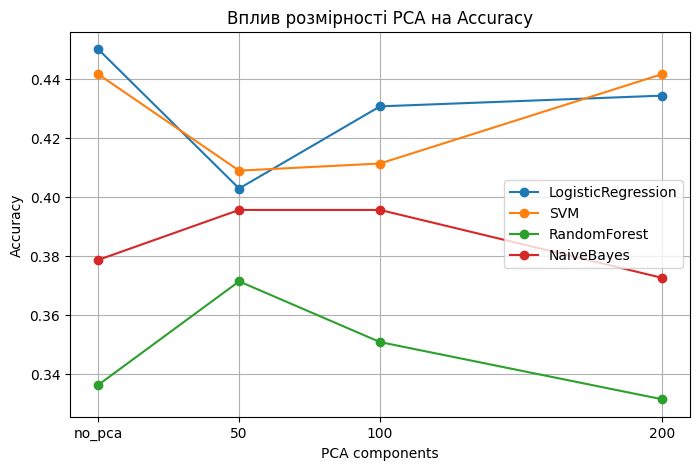

In [10]:
plt.figure(figsize=(8,5))
for name in models:
    sub = df_results[df_results['model']==name]
    # упорядкуємо по n_components (приведемо "no_pca" до 0 для візуалізації)
    def comp_to_num(x):
        return 0 if x=="no_pca" else int(x)
    sub = sub.copy()
    sub['comp_num'] = sub['n_components'].apply(comp_to_num)
    sub = sub.sort_values('comp_num')
    plt.plot(sub['comp_num'], sub['accuracy'], marker='o', label=name)
plt.xticks([0]+pca_components, labels=['no_pca']+pca_components)
plt.xlabel("PCA components")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Вплив розмірності PCA на Accuracy")
plt.grid(True)
plt.show()

На графіку показано, як зміна кількості компонент головних компонент (PCA) впливає на точність класифікації для чотирьох моделей: Logistic Regression, SVM, Random Forest та Naive Bayes. Найвищу точність демонструють Logistic Regression і SVM без застосування PCA (близько 0.46–0.47), що свідчить про те, що початкові векторні ознаки вже містять достатньо інформації для ефективної класифікації. При зниженні розмірності до 50 компонент точність помітно зменшується, що пов’язано із втратою частини корисних ознак. Подальше збільшення кількості компонент до 100 і 200 покращує результати, особливо для Naive Bayes, якому PCA допомагає усунути надлишковий шум. Для Random Forest точність залишається майже незмінною, що вказує на його відносну стійкість до розмірності ознак. Загалом, PCA не забезпечує значного приросту якості, однак при оптимальному виборі кількості компонент може частково стабілізувати роботу деяких моделей.

11.	Знаходимо Confusion matrix для найкращої моделі та виводимо теплову мапу.

Best model: LogisticRegression with n_components: no_pca


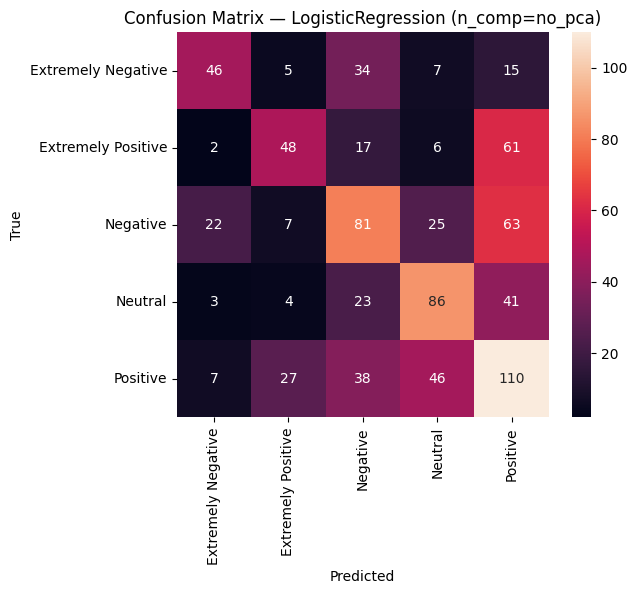

In [11]:
# знаходимо найкращу модель у df_results за macro_f1
best_row = df_results.loc[df_results['macro_f1'].idxmax()]
best_model_name = best_row['model']
best_ncomp = best_row['n_components']
print("Best model:", best_model_name, "with n_components:", best_ncomp)

# дістаємо confusion matrix
if best_ncomp == "no_pca":
    cm = results_no_pca[best_model_name]['confusion_matrix']
else:
    cm = results_pca[int(best_ncomp)][best_model_name]['confusion_matrix']

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title(f"Confusion Matrix — {best_model_name} (n_comp={best_ncomp})")
plt.show()

Матриця конфузії відображає результати класифікації твітів за допомогою моделі Logistic Regression без застосування PCA. Найбільше правильних передбачень спостерігається для класів Positive, Negative та Neutral, що свідчить про здатність моделі коректно розпізнавати основні типи тональності. Водночас між близькими за змістом категоріями, такими як Extremely Positive ↔ Positive та Extremely Negative ↔ Negative, спостерігається значна кількість перехресних помилок. Це вказує на те, що модель добре визначає загальний емоційний напрям повідомлення (позитивний чи негативний), проте гірше розрізняє інтенсивність емоції. Незважаючи на це, більшість значень зосереджені вздовж головної діагоналі, що підтверджує загальну стабільність моделі та її достатню ефективність для базового аналізу тональності текстів.

12.	Збереження моделі і пайплайн:

In [12]:
# приклад збереження: якщо best used PCA -> треба зберегти і PCA і модель
if best_ncomp == "no_pca":
  final_clf = models[best_model_name]
  final_clf.fit(X_train, y_train)
  joblib.dump({"model": final_clf, "label_encoder": le}, "final_model_no_pca.joblib")
else:
  pca = PCA(n_components=int(best_ncomp), random_state=42)
  X_train_p = pca.fit_transform(X_train)
  final_clf = models[best_model_name]
  final_clf.fit(X_train_p, y_train)
  joblib.dump({"model": final_clf, "pca": pca, "label_encoder": le}, "final_model_with_pca.joblib")

13.	Робимо прогноз для нового тексту.

In [13]:
from sentence_transformers import SentenceTransformer

model_st = SentenceTransformer('all-MiniLM-L6-v2')

# 2. Якщо найкраща модель використовує PCA
saved = {"model": final_clf, "label_encoder": le}

def predict_text(text, model_st, saved):
    txt = clean_text(text)
    emb = model_st.encode([txt])
    pred = saved['model'].predict(emb)
    return saved['label_encoder'].inverse_transform(pred)[0]

print(predict_text("I feel optimistic about vaccine progress", model_st, saved))

Positive
